In [1]:
%load_ext autoreload
%autoreload 2

# Multi-Station QC Evaluation

This notebook loads hourly observations for three stations, converts them to daily values, and runs the modular QC flow for each station. The station selection uses the shared SQL query for network 2 and the requested variables.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import sqlalchemy as sa
from sqlalchemy.orm import Session
# Make the function folder and package root available
sys.path.append(os.path.abspath('./func/'))
sys.path.append(os.path.abspath('../../'))


save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
engine = sa.create_engine(db_url, echo=False)
session = Session(engine)
session

In [3]:
from visualizaion_func import *

In [2]:
# replace with the three station IDs you want to evaluate
station_id = [2742]

sql_text = sa.text(
    """
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'pcpn_amt_pst1hr',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_station = pd.read_sql(sql_text, conn, params={
        "stations": tuple(station_id)})

print("Loaded observations for",
      df_station["station_id"].nunique(), "stations")
print(df_station.head())

Loaded observations for 1 stations
   station_id            obs_time             net_var_name  datum
0        2742 2001-11-01 18:00:00  MINIMUM_AIR_TEMPERATURE    3.1
1        2742 2001-11-01 18:00:00  MAXIMUM_AIR_TEMPERATURE    3.6
2        2742 2001-11-01 19:00:00  MAXIMUM_AIR_TEMPERATURE    3.2
3        2742 2001-11-01 19:00:00  MINIMUM_AIR_TEMPERATURE    3.0
4        2742 2001-11-01 20:00:00  MAXIMUM_AIR_TEMPERATURE    3.2


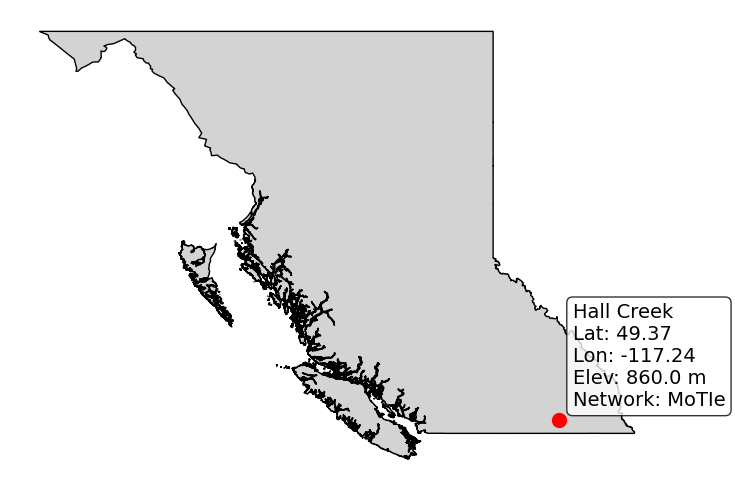

In [46]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# =========================================================
# 1. Read station info from SQL
# =========================================================
query = """
SELECT DISTINCT
    m.station_name,
    m.lat,
    m.lon,
    m.elev,
    s.network_id,
    n.network_name,
    n.description
FROM meta_history AS m
JOIN meta_station AS s
    ON m.station_id = s.station_id
JOIN meta_network AS n
    ON s.network_id = n.network_id
WHERE s.station_id = '2742'
"""

# Example:

with engine.begin() as conn:
    df = pd.read_sql(query, conn)

# Your shapefile path
shp_path = "/workspaces/crmprtd/CCCR2019/CCCR2019.shp"

canada = gpd.read_file(shp_path)

# ---------------------------------------------------------
# Select British Columbia
# ---------------------------------------------------------
bc = canada[canada["Region"] == "British Columbia"]

# =========================================================
# 3. Create GeoDataFrame for station
# =========================================================
station_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)

# Make CRS match
station_gdf = station_gdf.to_crs(bc.crs)

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Plot BC boundary
bc.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black"
)

# Plot station
station_gdf.plot(
    ax=ax,
    color="red",
    markersize=100
)

# =========================================================
# 5. Add annotation
# =========================================================
row = df.iloc[0]

info_text = (
    f"{row['station_name']}\n"
    f"Lat: {row['lat']:.2f}\n"
    f"Lon: {row['lon']:.2f}\n"
    f"Elev: {row['elev']} m\n"
    f"Network: {row['network_name']}"
)

ax.annotate(
    info_text,
    xy=(row['lon'], row['lat']),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=14,
    bbox=dict(boxstyle="round", fc="white", alpha=0.8)
)

# =========================================================
# 6. Improve map
# =========================================================
ax.set_title("Station Location in British Columbia")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("")

ax.set_xlabel("")
ax.set_ylabel("")

ax.axis("off")
plt.tight_layout()
plt.show()

In [14]:
from visualizaion_func import *
from func_run_qc_pipeline import *

value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}


daily_all = build_daily_all(df_station)

In [ ]:

result = run_qc_result_pipeline(
    daily_all,
    value_cols
)
daily_cleaned = result["daily_cleaned"]

daily_all['temp']
daily_cleaned['temp']

obs_time
2020-01-08          NaN
2020-01-09    -9.886957
2020-01-10    -8.960870
2020-01-11    -3.378261
2020-01-12    -2.233333
                ...    
2026-05-10    13.191304
2026-05-11    12.475000
2026-05-12    14.330435
2026-05-13    11.787500
2026-05-14          NaN
Freq: D, Name: temp, Length: 2319, dtype: float64

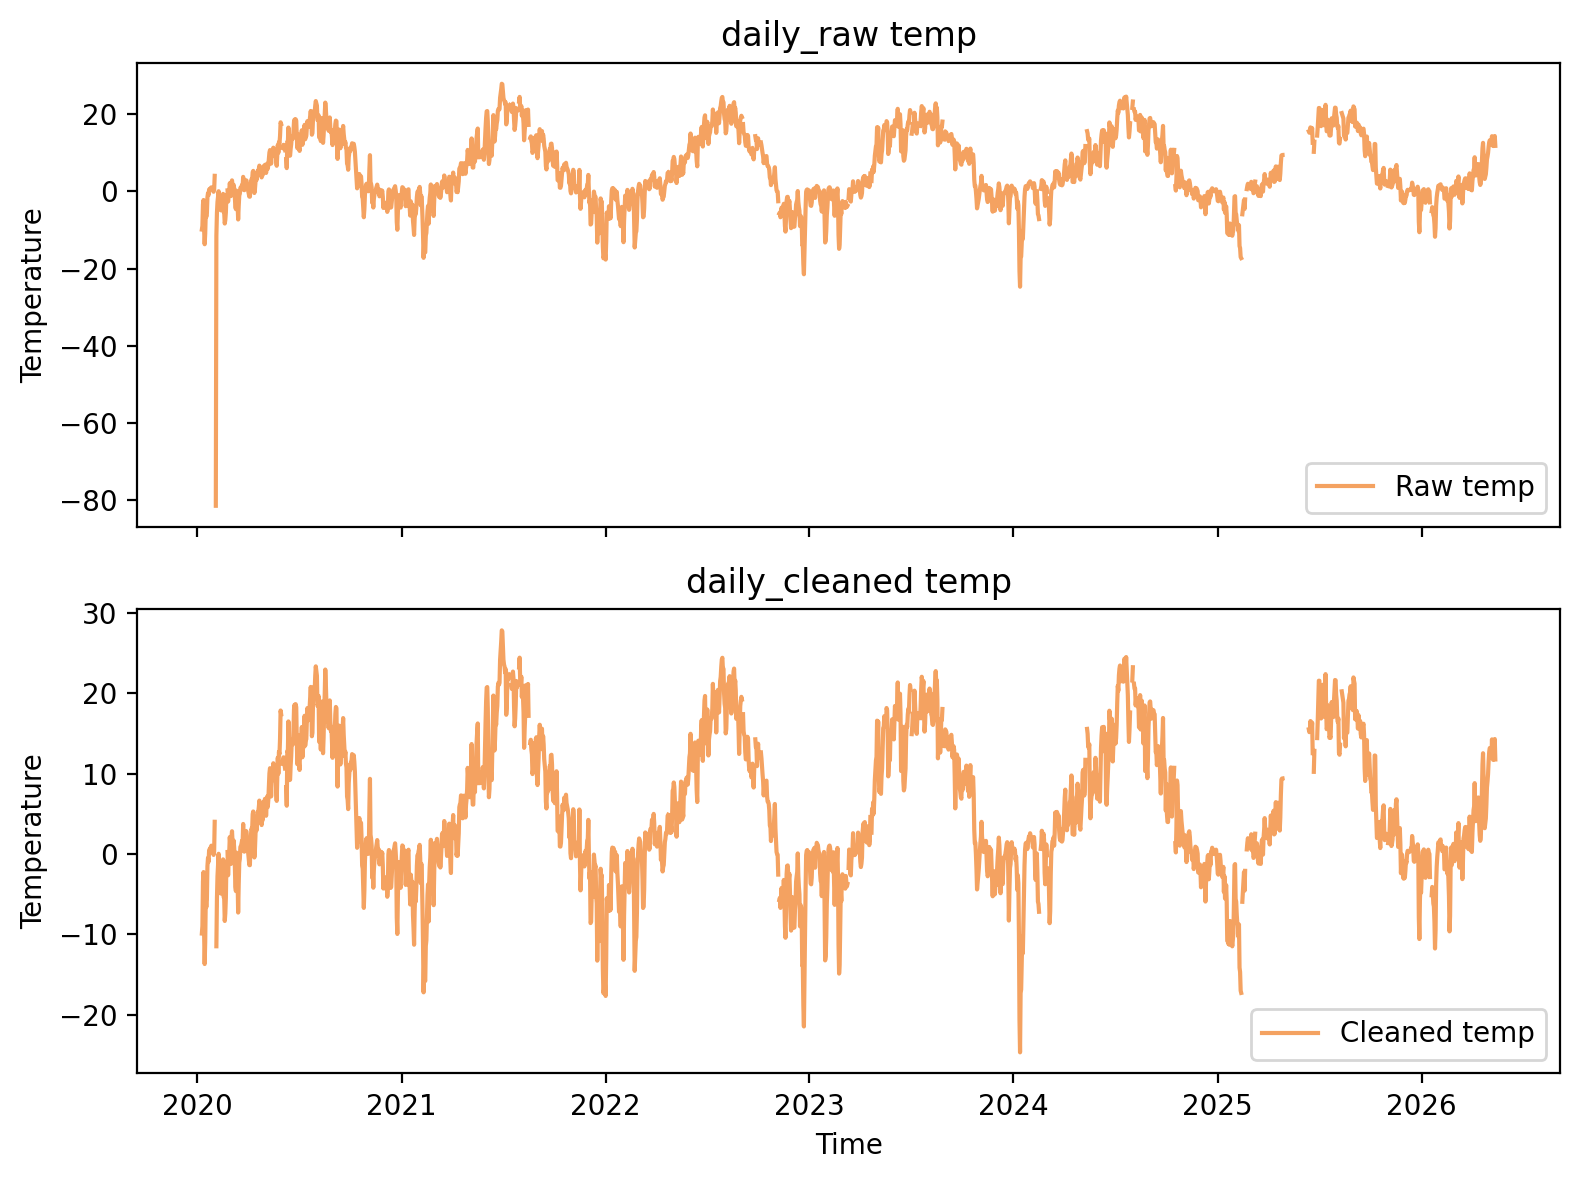

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, dpi=200)

# Top panel: raw data
axes[0].plot(daily_all['temp'], label='Raw temp', color='#f4a261')
axes[0].set_title('daily_raw temp')
axes[0].set_ylabel('Temperature')
# axes[0].set_ylim(-1000, 50)
axes[0].legend()

# Bottom panel: cleaned data
axes[1].plot(daily_cleaned['temp'], label='Cleaned temp', color='#f4a261')
axes[1].set_title('daily_cleaned temp')
axes[1].set_ylabel('Temperature')
axes[1].legend(loc='lower right')

plt.xlabel('Time')
plt.tight_layout()
plt.show()